In [75]:
import pandas as pd

In [76]:
country_code = "TUR"

In [77]:
def extract_data(path, value_variable):

    df = pd.read_csv(path)

    df = df[ df['Country Code'] == country_code ]

    # Transpose the dataset because we want year: value format
    df = df.T

    # Remove the first 4 rows which are identifier of the dataset
    df = df[4:]

    # Set year as index of the dataframe
    df = df.reset_index()

    df = df.rename(columns={ 'index': 'year', 244: value_variable })
    df.set_index('year', inplace=True)

    # Remove records with NaN
    df = df.dropna()

    return df

In [78]:
# We extract the datasets and merge them


deflator = extract_data("deflator.csv", "deflator")
ngdp = extract_data("ngdp.csv", "ngdp")
rgdp = extract_data("rgdp.csv", "rgdp")

df = pd.merge(deflator, ngdp, on="year", how="inner")
df = pd.merge(df, rgdp, on="year", how="inner")

df.head()

,deflator,ngdp,rgdp
year,,,
1961,4.3734,71900.0,124611001186.880997
1962,5.788938,80300.0,131553614123.080002
1963,6.416694,93200.0,143480666744.716003
1964,2.352437,100600.0,151313357837.005005
1965,4.117856,107700.0,155585735198.701996


In [79]:
df = df[df.index.astype(int) > 2000]
df.tail()

,deflator,ngdp,rgdp
year,,,
2020,14.733907,5141710600900.0,1826405252300.0
2021,29.3059,7433799908300.0,2042123701700.0
2022,95.52553,15325857491800.0,2153240249400.0
2023,68.279757,27091469064700.0,2261873883500.0
2024,59.280076,44587225440200.0,2337140521100.0


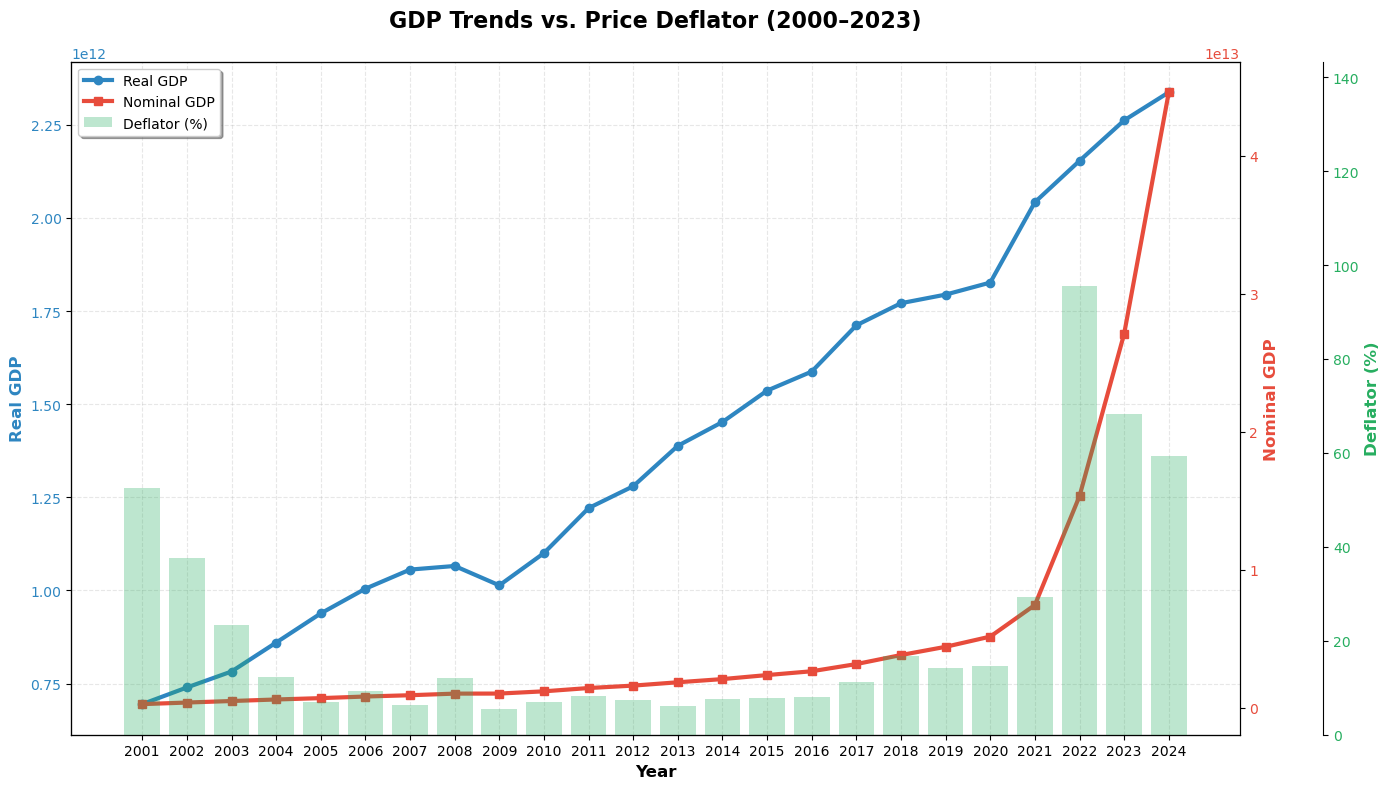

In [80]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax1 = plt.subplots(figsize=(14, 8), dpi=100)

# 1. Plot Real GDP (Left Y-Axis - Blue Line)
color_rgdp = '#2E86C1'
ax1.plot(df.index, df['rgdp'], color=color_rgdp, linewidth=3, marker='o', label='Real GDP')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Real GDP', color=color_rgdp, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_rgdp)

# 2. Plot Nominal GDP (Right Y-Axis - Red Line)
ax2 = ax1.twinx()
color_ngdp = '#E74C3C'
ax2.plot(df.index, df['ngdp'], color=color_ngdp, linewidth=3, marker='s', label='Nominal GDP')
ax2.set_ylabel('Nominal GDP', color=color_ngdp, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_ngdp)

# 3. Plot Deflator (Third Y-Axis - Green Bars)
ax3 = ax1.twinx()
# This command moves the third axis further to the right so it doesn't overlap NGDP
ax3.spines['right'].set_position(('outward', 60)) 
color_def = '#27AE60'
ax3.bar(df.index, df['deflator'], color=color_def, alpha=0.3, label='Deflator (%)')
ax3.set_ylabel('Deflator (%)', color=color_def, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_def)
ax3.set_ylim(0, df['deflator'].max() * 1.5) # Scale bars to stay in the bottom half

# 4. Legend & Title
legend_elements = [
    plt.Line2D([0], [0], color=color_rgdp, lw=3, marker='o', label='Real GDP'),
    plt.Line2D([0], [0], color=color_ngdp, lw=3, marker='s', label='Nominal GDP'),
    Patch(facecolor=color_def, alpha=0.3, label='Deflator (%)')
]
ax1.legend(handles=legend_elements, loc='upper left', frameon=True, shadow=True)

plt.title("GDP Trends vs. Price Deflator (2000–2023)", fontsize=16, fontweight='bold', pad=25)
ax1.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()